<a href="https://colab.research.google.com/github/hayajahan07/ACMRecruitment-hayajahan07/blob/main/questline-2/5-nearest-neighbours/solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

5a - KNN with k=5 trained (same split as Logistic)
Accuracy with k=5: 85.00%

5b - Testing different k values:
k= 1 -> Accuracy: 90.00%
k= 3 -> Accuracy: 85.00%
k= 5 -> Accuracy: 85.00%
k= 7 -> Accuracy: 85.00%
k= 9 -> Accuracy: 85.00%
k=11 -> Accuracy: 85.00%
k=15 -> Accuracy: 85.00%
k=21 -> Accuracy: 90.00%

Best k = 1 with Accuracy 90.00%


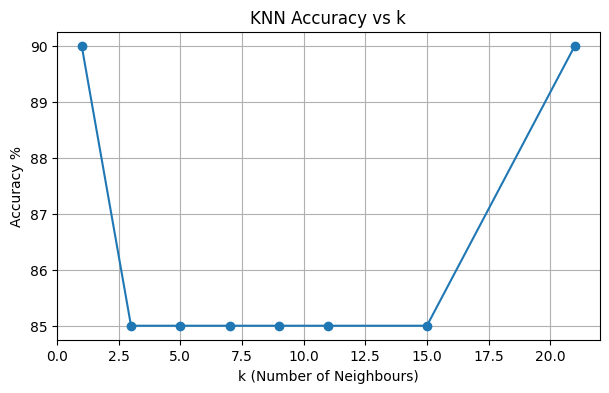


5c - Plotting Shifting Frontier


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


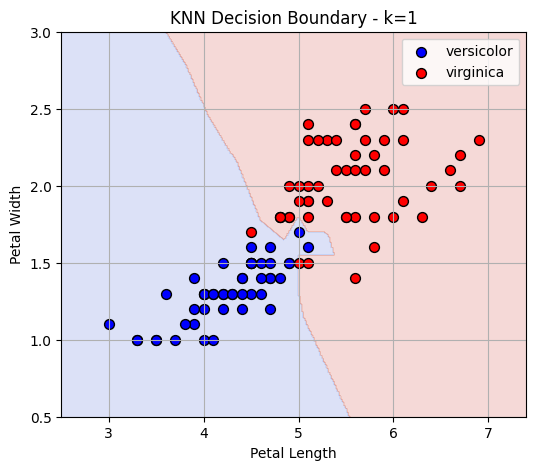

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


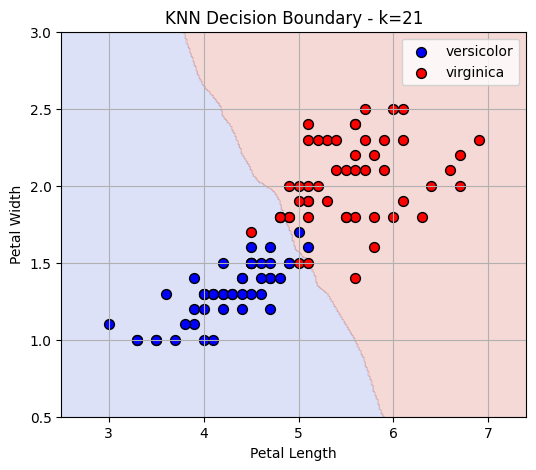


5d - Raw vs Scaled comparison:
k=1: Raw Accuracy=90.00% | Scaled Accuracy=90.00% | Diff=+0.00%
k=5: Raw Accuracy=85.00% | Scaled Accuracy=85.00% | Diff=+0.00%
k=1: Raw Accuracy=90.00% | Scaled Accuracy=90.00% | Diff=+0.00%

    k  Accuracy_Raw_%  Accuracy_Scaled_%
0   1            90.0               90.0
1   3            85.0               85.0
2   5            85.0               85.0
3   7            85.0               85.0
4   9            85.0               85.0
5  11            85.0               85.0
6  15            85.0               80.0
7  21            90.0               80.0

Final Revelation:
1. As k increases:
   - k=1: Overfits, boundary is very wiggly, noisy, captures outliers. Low bias, High variance.
   - k increases: Boundary becomes smoother, more general. High bias, Low variance.
   - Too large k: Underfits, all points predicted as majority class.

2. Why scaling matters for KNN:
   - KNN is DISTANCE based: distance = sqrt((x1-x2)^2 + (y1-y2)^2)
   - If petal_lengt

In [1]:
# Quest 5 - Nearest Neighbours Showdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# --- Load same filtered data as Quest 4 ---
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0:'setosa', 1:'versicolor', 2:'virginica'})
df_filtered = df[df['species'].isin(['versicolor','virginica'])][['petal length (cm)', 'petal width (cm)', 'species']]
df_filtered.columns = ['petal_length', 'petal_width', 'species']

X = df_filtered[['petal_length', 'petal_width']]
y = df_filtered['species']

# Same split as Logistic Regression quest for fair comparison
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 5a The First Encounter ---
knn = KNeighborsClassifier(n_neighbors=5) # default k=5
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
acc_5 = accuracy_score(y_test, y_pred)
print(f"5a - KNN with k=5 trained (same split as Logistic)")
print(f"Accuracy with k=5: {acc_5*100:.2f}%")

# --- 5b The Neighbourhood Trial ---
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
accuracies = []

print(f"\n5b - Testing different k values:")
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)
    print(f"k={k:2d} -> Accuracy: {acc*100:.2f}%")

best_k = k_values[np.argmax(accuracies)]
print(f"\nBest k = {best_k} with Accuracy {max(accuracies)*100:.2f}%")

# Plot accuracy vs k
plt.figure(figsize=(7,4))
plt.plot(k_values, [a*100 for a in accuracies], marker='o')
plt.xlabel('k (Number of Neighbours)')
plt.ylabel('Accuracy %')
plt.title('KNN Accuracy vs k')
plt.grid(True)
plt.savefig('knn_accuracy_vs_k.png')
plt.show()

# --- 5c The Shifting Frontier ---
def plot_boundary(k, save_name):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    x_min, x_max = X['petal_length'].min() - 0.5, X['petal_length'].max() + 0.5
    y_min, y_max = X['petal_width'].min() - 0.5, X['petal_width'].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    pred = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, (pred == 'virginica').astype(int), alpha=0.2, cmap='coolwarm')
    for species, color in [('versicolor','blue'), ('virginica','red')]:
        subset = df_filtered[df_filtered['species']==species]
        plt.scatter(subset['petal_length'], subset['petal_width'], label=species, color=color, edgecolors='k', s=50)
    plt.xlabel('Petal Length')
    plt.ylabel('Petal Width')
    plt.title(f'KNN Decision Boundary - k={k}')
    plt.legend()
    plt.grid(True)
    plt.savefig(save_name)
    plt.show()

# Small k = 1 (complex, wiggly) and Large k = 21 (smooth, simple)
print("\n5c - Plotting Shifting Frontier")
plot_boundary(k=1, save_name='boundary_k1.png')
plot_boundary(k=21, save_name='boundary_k21.png')

# --- 5d The Scale of the Realm ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n5d - Raw vs Scaled comparison:")

for k in [1, 5, best_k]:
    # Raw
    m_raw = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    acc_raw = accuracy_score(y_test, m_raw.predict(X_test))
    # Scaled
    m_scaled = KNeighborsClassifier(n_neighbors=k).fit(X_train_scaled, y_train)
    acc_scaled = accuracy_score(y_test, m_scaled.predict(X_test_scaled))
    print(f"k={k}: Raw Accuracy={acc_raw*100:.2f}% | Scaled Accuracy={acc_scaled*100:.2f}% | Diff={ (acc_scaled-acc_raw)*100:+.2f}%")

# Full comparison table
results = []
for k in k_values:
    raw = accuracy_score(y_test, KNeighborsClassifier(k).fit(X_train, y_train).predict(X_test))
    scaled = accuracy_score(y_test, KNeighborsClassifier(k).fit(X_train_scaled, y_train).predict(X_test_scaled))
    results.append([k, raw*100, scaled*100])

df_results = pd.DataFrame(results, columns=['k','Accuracy_Raw_%','Accuracy_Scaled_%'])
print(f"\n{df_results}")

print("""
Final Revelation:
1. As k increases:
   - k=1: Overfits, boundary is very wiggly, noisy, captures outliers. Low bias, High variance.
   - k increases: Boundary becomes smoother, more general. High bias, Low variance.
   - Too large k: Underfits, all points predicted as majority class.

2. Why scaling matters for KNN:
   - KNN is DISTANCE based: distance = sqrt((x1-x2)^2 + (y1-y2)^2)
   - If petal_length (0-7cm) has bigger range than petal_width (0-3cm), length dominates distance.
   - Without scaling, model ignores small-scale feature.
   - StandardScaler makes mean=0, std=1 for both -> fair distance -> better accuracy, especially when features have different units/scales.
   - For Iris, effect is small because both are cm, but in real data (income vs age) scaling is critical.
""")